Exercise 1 : duplicate detection and removal

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
raw_titanic = pd.read_csv('Titanic_Dataset.csv')
tit = raw_titanic.copy()
print(tit.head())

      



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [104]:
print(tit.describe()) 

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [105]:
print(tit.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [106]:
print(tit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [107]:
print(tit.shape)

(891, 12)


In [108]:
print(tit.duplicated().sum())
tit_duplicated = tit[tit.duplicated(keep=False)]
print(tit_duplicated)
print(f'number of rows before removing duplicates: {tit.shape[0]}')
tit= tit.drop_duplicates()
print(f'number of rows after removing duplicates: {tit.shape[0]}')

0
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
number of rows before removing duplicates: 891
number of rows after removing duplicates: 891


no dupilcates found

EXERCISE 2: Missing Values

In [109]:
print(tit.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [110]:
missing_value = tit.isnull().sum()
missing_percent = tit.isnull().sum() / tit.shape[0] * 100
data_missing = pd.DataFrame({'missing count': missing_value,
                             'missing %' : missing_percent})
print(data_missing[data_missing['missing count'] >0])

          missing count  missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


since the missing value of Cabin is above 50% , it will be dropped.

missing values of age is less than 50%, so the missing data will be filled in with the age median

Embarked is less than 5%, the modal value will be used to fill in

In [111]:
print(f'row and column before drop is {tit.shape}')
tit = tit.drop(columns=['Cabin'])
print(f'row and column after drop is {tit.shape}')

row and column before drop is (891, 12)
row and column after drop is (891, 11)


In [112]:
tit.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [155]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

age_fill= SimpleImputer(strategy='median')
tit['Age'] = age_fill.fit_transform(tit[['Age']])
print(tit['Age'].isnull().sum())

0


In [114]:
tit['Embarked'] = tit['Embarked'].fillna(tit['Embarked'].mode()[0])
print(tit.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Exercise 3 : Feature Learning

In [115]:
tit['Family_size'] = tit['SibSp'] + tit['Parch'] + 1
print(tit.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  Family_size  
0      0         A/5 21171   7.2500        S            2  
1      0          PC 17599  71.2833        C            2  
2      0  STON/O2. 3101282   7.9250        S            1  
3      0            113803  53.1000        S            2  
4      0            

In [116]:
tit['title'] = tit['Name'].str.extract('([A-Za-z]+)\.')
print(tit['title'].value_counts())

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [117]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Master': 'Master',
    'Don': 'Other',
    'Rev': 'Other',
    'Dr': 'Other',
    'Mme': 'Other',
    'Ms': 'Miss',
    'Major': 'Other',
    'Lady': 'Other',
    'Sir': 'Other',
    'Mlle': 'Other',
    'Col': 'Other',
    'Capt': 'Other',
    'Countess': 'Other',
    'Jonkheer': 'Other'
}
tit['title'] = tit['title'].map(title_mapping)
print(tit['title'].value_counts())
    


title
Mr        517
Miss      183
Mrs       125
Master     40
Other      26
Name: count, dtype: int64


exercise 4 : Outliers


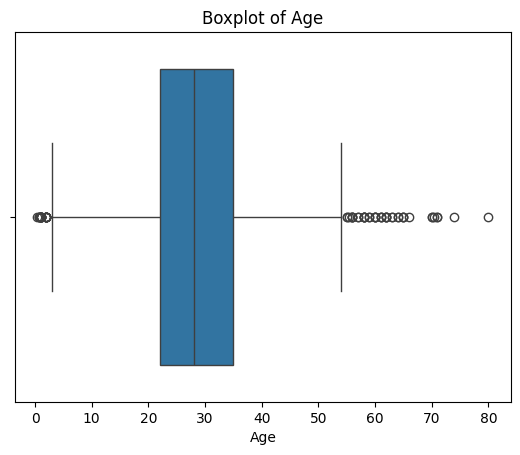

In [101]:
age_boxplot = sns.boxplot(x=tit['Age'])
(plt.title('Boxplot of Age'))
plt.show()



Text(0.5, 1.0, 'Boxplot of Fare')


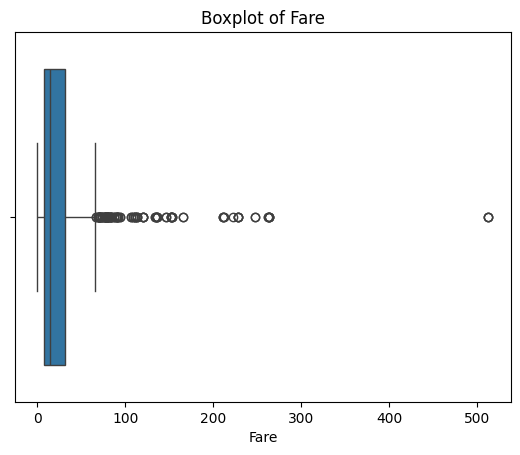

In [102]:
fare_boxplot = sns.boxplot(x=tit['Fare'])
print(plt.title('Boxplot of Fare'))
plt.show()


Inter-Quartile for outliers detection for Fare

In [121]:
Q1 = tit['Fare'].quantile(0.25)
Q2 = tit['Fare'].quantile(0.5)
Q3 = tit['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = tit[(tit['Fare'] < lower_bound) | (tit['Fare'] > upper_bound)]
outliers_percent = (len(outliers) / len(tit)) * 100
print(f'Number of outliers: {len(outliers)}')
print(f'Percentage of outliers: {outliers_percent:.2f}%')

Number of outliers: 116
Percentage of outliers: 13.02%


In [123]:
Fare_cap98= tit['Fare'].quantile(0.98)
outliers_98 = tit[tit['Fare'] > Fare_cap98]
print(f'Number of outliers at 98% cap: {len(outliers_98)}')
print(f'Percentage of outliers: {(len(outliers_98) / len(tit)) * 100:.2f}%')

Number of outliers at 98% cap: 17
Percentage of outliers: 1.91%


In [124]:
Fare_cap99 = tit['Fare'].quantile(0.99)
outliers_99 = tit[tit['Fare'] > Fare_cap99]
print(f'Number of outliers at 99% cap: {len(outliers_99)}')
print(f'Percentage of outliers: {(len(outliers_99) / len(tit)) * 100:.2f}%')

Number of outliers at 99% cap: 9
Percentage of outliers: 1.01%


There is a slight decrement of 0.90% from cap98 to cap 99

In [128]:
print(tit['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


<Axes: xlabel='Fare', ylabel='Count'>

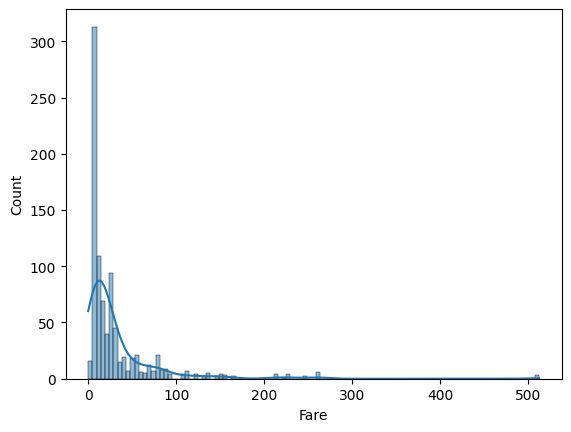

In [129]:
sns.histplot(data=tit, x="Fare", kde=True)

In [134]:
tit['log_fare'] = np.log(tit['Fare'] +1 )
print(tit['log_fare'].describe())

count    891.000000
mean       2.962246
std        0.969048
min        0.000000
25%        2.187218
50%        2.737881
75%        3.465736
max        6.240917
Name: log_fare, dtype: float64


<Axes: xlabel='log_fare', ylabel='Count'>

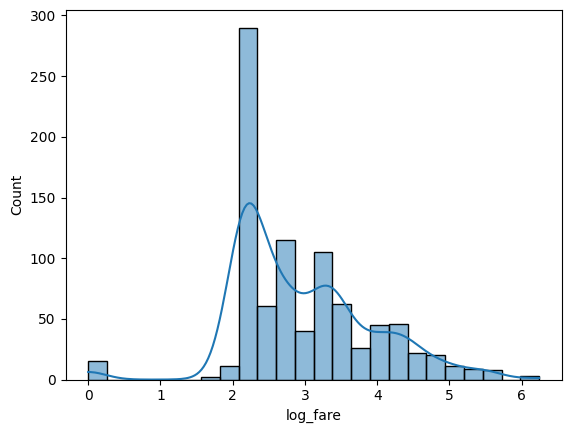

In [132]:
sns.histplot(data=tit, x="log_fare", kde=True)

comaparing the histplot for fare and log_fare, log fare column reduces the impact of the outliers

Axes(0.125,0.11;0.775x0.77)
number of outliers after log transformation: 17


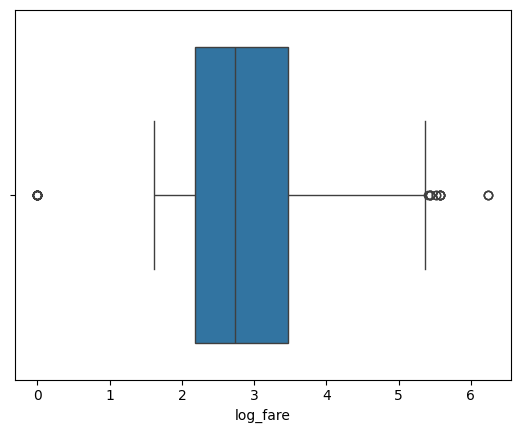

In [137]:
print(sns.boxplot(data=tit, x="log_fare"))
log_fare_outliers = tit[tit['log_fare'] > tit['log_fare'].quantile(0.98)]
print(f'number of outliers after log transformation: {len(log_fare_outliers)}')

Inter_Quartile detection for outliers for Age

In [122]:
Q1 = tit['Age'].quantile(0.25)
Q2 = tit['Age'].quantile(0.5)
Q3 = tit['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = tit[(tit['Age'] < lower_bound) | (tit['Age'] > upper_bound)]
outliers_percent = (len(outliers) / len(tit)) * 100
print(f'Number of outliers: {len(outliers)}')
print(f'Percentage of outliers: {outliers_percent:.2f}%')

Number of outliers: 66
Percentage of outliers: 7.41%


In [148]:
Age_upper= tit['Age'].quantile(0.98)
tit['Age_cap98'] = tit['Age'].clip(upper=Age_upper)
outliers_98 = tit[tit['Age'] > tit['Age_cap98']]
print(f'Number of outliers at 98% cap: {len(outliers_98)}')
print(f'Percentage of outliers: {(len(outliers_98) / len(tit)) * 100:.2f}%')
print(tit['Age_cap98'].describe())



Number of outliers at 98% cap: 15
Percentage of outliers: 1.68%
count    891.000000
mean      29.258889
std       12.720003
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       62.000000
Name: Age_cap98, dtype: float64


In [147]:
Age_cap99 = tit['Age'].quantile(0.99)
outliers_99 = tit[tit['Age'] > Age_cap99]
print(f'Number of outliers at 99% cap: {len(outliers_99)}')
print(f'Percentage of outliers: {(len(outliers_99) / len(tit)) * 100:.2f}%')


Number of outliers at 99% cap: 8
Percentage of outliers: 0.90%


There is a slight decrement of 0.78 from cap98 to cap99

In [127]:
print(tit['Age'].describe())

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


<Axes: xlabel='Age', ylabel='Count'>

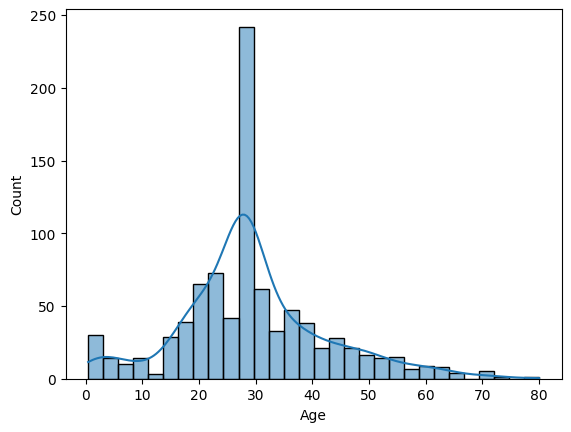

In [130]:
sns.histplot(data=tit, x="Age", kde=True)

Axes(0.125,0.11;0.775x0.77)


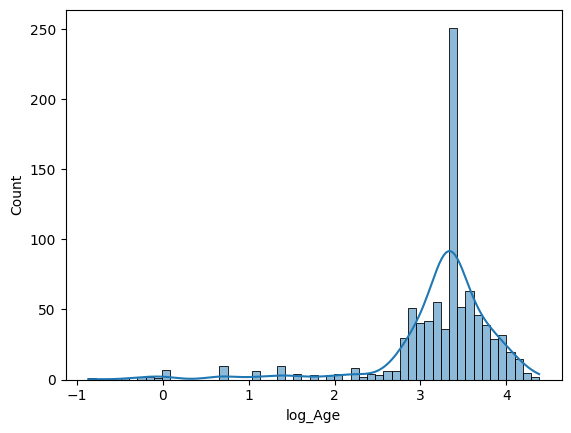

In [142]:
tit['log_Age'] = np.log(tit['Age'])
print(sns.histplot(data=tit, x="log_Age", kde=True))

at this stage log tranformation is not best for age distribution since its more skewed to right


<Axes: xlabel='log_Age'>

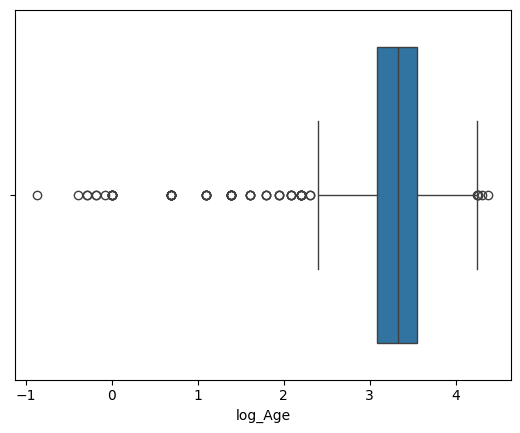

In [143]:
sns.boxplot(data=tit, x="log_Age")

Exercise 5:Data Standardization and Normalization

<Axes: xlabel='Age_cap98', ylabel='Count'>

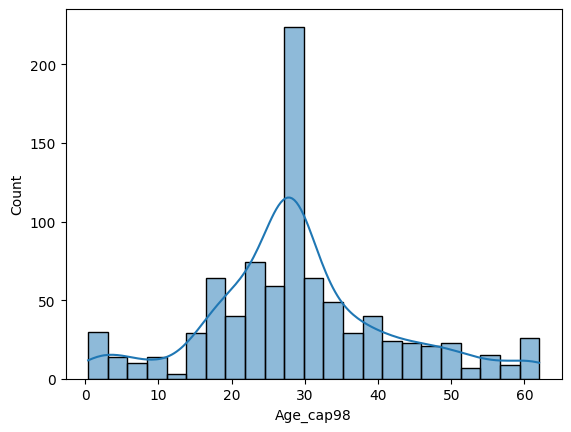

In [151]:
sns.histplot(data=tit, x='Age_cap98', kde=True)

<Axes: xlabel='log_fare', ylabel='Count'>

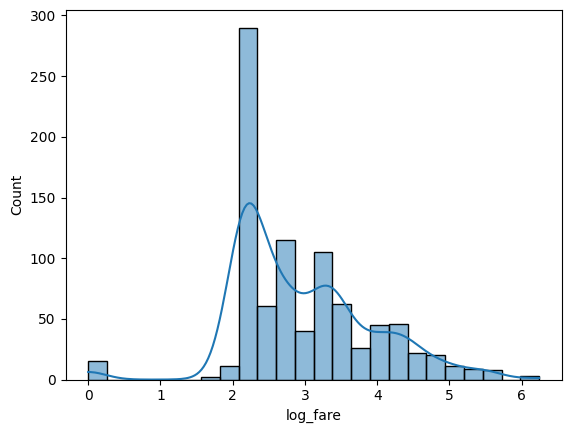

In [152]:
sns.histplot(data=tit, x='log_fare', kde=True)

In [156]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

tit['Age_scaled'] = std_scaler.fit_transform(tit[['Age_cap98']])
tit['Fare_scaled'] = minmax_scaler.fit_transform(tit[['log_fare']])
print(tit[['Age_cap98', 'Age_scaled', 'log_fare', 'Fare_scaled']].describe())

        Age_cap98    Age_scaled    log_fare  Fare_scaled
count  891.000000  8.910000e+02  891.000000   891.000000
mean    29.258889  1.674680e-16    2.962246     0.474649
std     12.720003  1.000562e+00    0.969048     0.155273
min      0.420000 -2.268481e+00    0.000000     0.000000
25%     22.000000 -5.709877e-01    2.187218     0.350464
50%     28.000000 -9.902481e-02    2.737881     0.438698
75%     35.000000  4.515986e-01    3.465736     0.555325
max     62.000000  2.575432e+00    6.240917     1.000000


Axes(0.125,0.11;0.775x0.77)


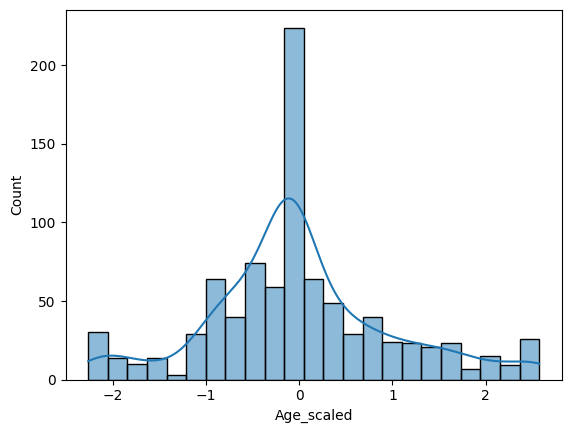

In [159]:
print(sns.histplot(data = tit, x = 'Age_scaled', kde = True))


Axes(0.125,0.11;0.775x0.77)


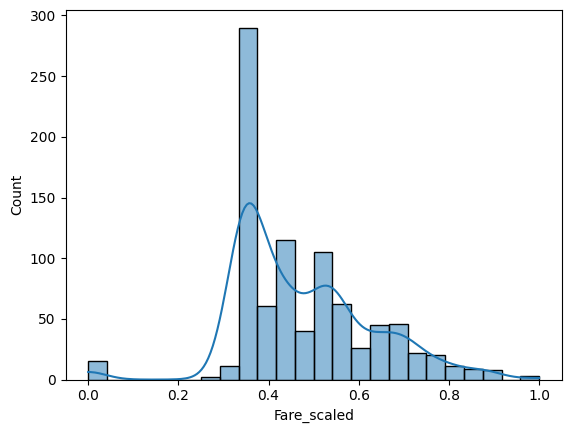

In [160]:
print(sns.histplot(data = tit, x = 'Fare_scaled', kde = True))

Exercise 6: Feature Coding

In [162]:
print(tit.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Family_size    0
title          0
log_fare       0
log_Age        0
Age_cap99      0
Age_cap98      0
Age_scaled     0
Fare_scaled    0
dtype: int64


In [171]:
print(tit[['Embarked', 'Sex', 'title']].head(20))

   Embarked     Sex   title
0         S    male      Mr
1         C  female     Mrs
2         S  female    Miss
3         S  female     Mrs
4         S    male      Mr
5         Q    male      Mr
6         S    male      Mr
7         S    male  Master
8         S  female     Mrs
9         C  female     Mrs
10        S  female    Miss
11        S  female    Miss
12        S    male      Mr
13        S    male      Mr
14        S  female    Miss
15        S  female     Mrs
16        Q    male  Master
17        S    male      Mr
18        S  female     Mrs
19        C  female     Mrs


In [182]:
tit_encoded = pd.get_dummies(tit,columns=['Sex','Embarked', 'title'], drop_first = True, dtype = int)
print(tit_encoded.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Family_size  ...  Age_cap98  Age_scaled  \
0         A/5 21171   7.2500            2  ...       22.0   -0.570988   
1          PC 17599  71.2833            2  ...       38.0    0.687580   
2  STON/O2. 3101282   7.9250            1  ...       26.0   -0.256346   
3            113803  53.1000      

In [185]:
tit['Family_mapping'] = tit['Family_size'].map({1:'alone', 2:'small', 3:'small'}).fillna('large')
print(tit['Family_mapping'].head(10))

0    small
1    small
2    alone
3    small
4    alone
5    alone
6    alone
7    large
8    small
9    small
Name: Family_mapping, dtype: object


Exercise 7 :Data Transformation for Age Feature

In [186]:
tit['Age'].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [202]:
tit['Stage_in_life']= pd.cut(tit['Age'], bins =[0, 12, 18, 60, 80],labels = ['child', 'teen', 'adult', 'senior'])
tit['Stage_in_life'].head(20)

0     adult
1     adult
2     adult
3     adult
4     adult
5     adult
6     adult
7     child
8     adult
9      teen
10    child
11    adult
12    adult
13    adult
14     teen
15    adult
16    child
17    adult
18    adult
19    adult
Name: Stage_in_life, dtype: category
Categories (4, object): ['child' < 'teen' < 'adult' < 'senior']

In [203]:
tit_encoded = pd.get_dummies(tit, columns = ['Stage_in_life'], drop_first=True, dtype =int)
tit_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,log_fare,log_Age,Age_cap99,Age_cap98,Age_scaled,Fare_scaled,Family_mapping,Stage_in_life_teen,Stage_in_life_adult,Stage_in_life_senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,2.110213,3.091042,65.0,22.0,-0.570988,0.338125,small,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,4.280593,3.637586,65.0,38.0,0.687580,0.685892,small,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,2.188856,3.258097,65.0,26.0,-0.256346,0.350727,alone,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,3.990834,3.555348,65.0,35.0,0.451599,0.639463,small,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,2.202765,3.555348,65.0,35.0,0.451599,0.352955,alone,0,1,0
